# Equilibrium Analysis

This Notebook contains all the plotting and calculations that were necessary for the equilibrium analysis in Section 6.1.2.

### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Patch

## Data Preperation

In [2]:
specs = {
    "A1": (
        [0.000, 0.045, 0.090] * 3,
        [0.000] * 3 + [0.045] * 3 + [0.090] * 3,
    ),
    "A2": (
        [0.000, 0.045, 0.090] * 3,
        [0.000] * 3 + [0.750] * 3 + [1.000] * 3,
    ),
    "B": (
        [0.000] * 3 + [0.045] * 3 + [0.090] * 3,
        [0.000, 0.045, 0.090] * 3,
    ),
    "C": (
        [0.000, 0.000, 0.045],
        [0.750, 1.000, 1.000],
    ),
}

frames = []

for experiment, (tau, benefit) in specs.items():
    data = pd.read_csv(f"raw_data/{experiment}.csv")

    data["configuration_id"] = data["id"]

    parameter_map = pd.DataFrame({
        "configuration_id": [
            f"{experiment}_{i}" for i in range(len(tau))
        ],
        "switching_cost": tau,
        "membership_benefit": benefit,
    })

    data = data.merge(
        parameter_map,
        on="configuration_id",
        how="inner",
        validate="many_to_one",
    )

    data["experiment"] = experiment
    data["analysis_included"] = True
    data["special_case"] = False
    frames.append(data)

df = pd.concat(frames, ignore_index=True)

# Remove the outlier seed, see stability_analysis.ipynb
final_results = df[
    ~(
        (df["experiment"] == "A2")
        & (df["configuration_id"] == "A2_8")
        & (df["seed"] == 8)
    )
].copy()

loss_columns = [
    "rel. loss0",
    "rel. loss1",
]

final_results[loss_columns] = (
    final_results[loss_columns].clip(lower=0)
)

## Figure 6.2

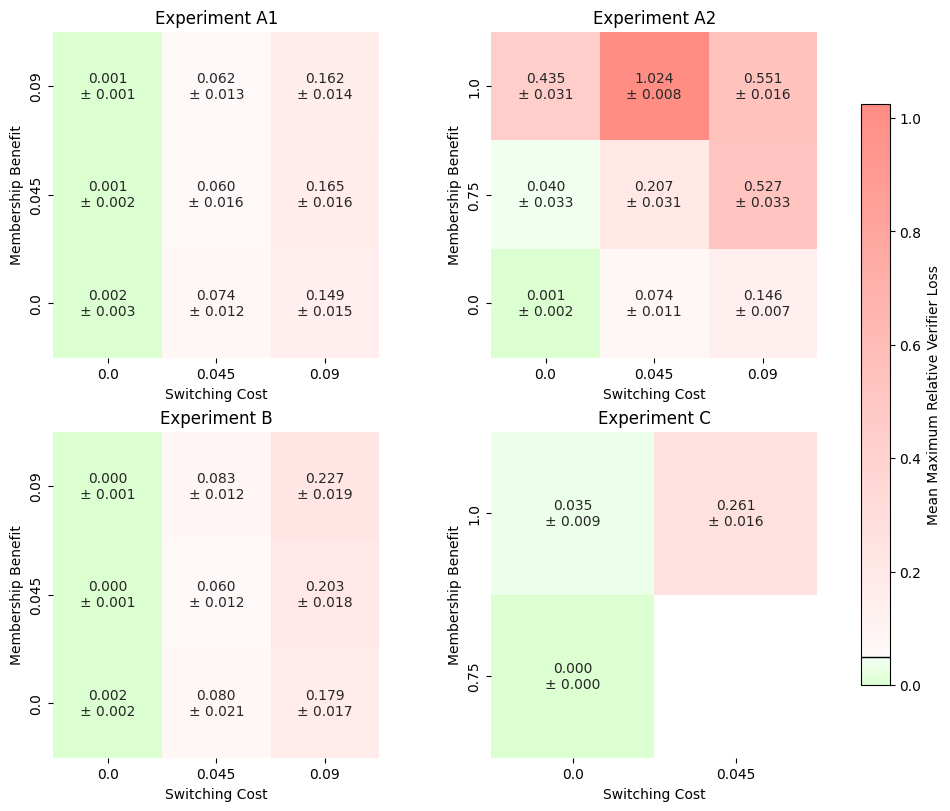

In [3]:
summaries = {}

for experiment in ["A1", "A2", "B", "C"]:
    data = final_results[
        (final_results["experiment"] == experiment)
    ].copy()

    data["max_relative_loss"] = data[
        [
            "rel. loss0",
            "rel. loss1",
        ]
    ].max(axis=1)

    # Remove repeated stage rows, each configuration_id and seed should only have one row as verifier loss is constant across each stage
    data = data.drop_duplicates(
        ["configuration_id", "seed"]
    )

    summary = (
        data.groupby(
            ["membership_benefit", "switching_cost"]
        )["max_relative_loss"]
        .agg(["mean", "std"])
        .reset_index()
    )

    summary["label"] = (
        summary["mean"].map("{:.3f}".format)
        + "\n± "
        + summary["std"].map("{:.3f}".format)
    )

    means = summary.pivot(
        index="membership_benefit",
        columns="switching_cost",
        values="mean",
    ).sort_index(ascending=False)

    labels = summary.pivot(
        index="membership_benefit",
        columns="switching_cost",
        values="label",
    ).sort_index(ascending=False)

    summaries[experiment] = (means, labels)


# Shared color scale
threshold = 0.05

vmax = max(
    means.max().max()
    for means, labels in summaries.values()
)

vmax = max(vmax, threshold + 0.001)
threshold_position = threshold / vmax

# Green up to 0.05; light-to-dark red above 0.05
cmap = LinearSegmentedColormap.from_list(
    "verifier_loss",
    [
        (0.0, "#DBFFD0"),
        (threshold_position, "#F5FFF6"),
        (threshold_position + 0.0001, "#FFF9F9"),
        (1.0, "#FF8D84"),
    ],
)

norm = Normalize(vmin=0, vmax=vmax)


# Four heatmaps in one figure
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    constrained_layout=True,
)

for ax, (experiment, (means, labels)) in zip(
    axes.flat,
    summaries.items(),
):
    sns.heatmap(
        means,
        annot=labels,
        fmt="",
        cmap=cmap,
        norm=norm,
        cbar=False,
        square=True,
        mask=means.isna(),
        ax=ax,
    )

    ax.set_title(f"Experiment {experiment}")
    ax.set_xlabel("Switching Cost")
    ax.set_ylabel("Membership Benefit")


# Shared color bar
colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes.ravel().tolist(),
    shrink=0.8,
)

colorbar.set_label(
    "Mean Maximum Relative Verifier Loss"
)

colorbar.ax.axhline(
    threshold,
    color="black",
    linewidth=1,
)

plt.show()

## Figure 6.1

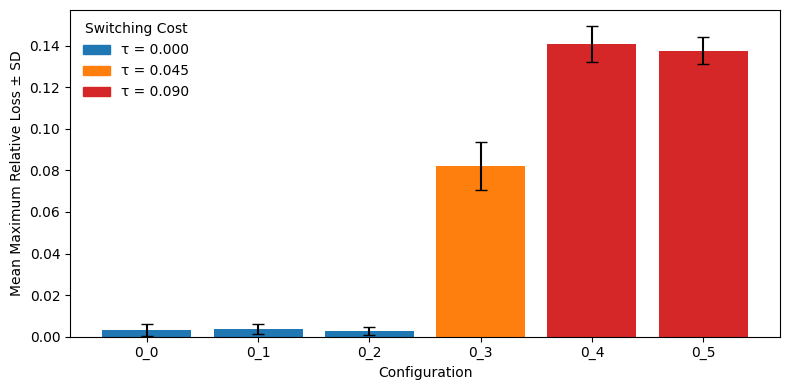

In [4]:
baseline = pd.read_csv("raw_data/0.csv")

switching_cost_map = {
    "0_0": 0.000,
    "0_1": 0.000,
    "0_2": 0.000,
    "0_3": 0.045,
    "0_4": 0.090,
    "0_5": 0.090,
}

# Verifier losses are identical across stage rows
baseline = baseline[baseline["stage"] == 0].copy()

baseline["switching_cost"] = baseline["id"].map(
    switching_cost_map
)

baseline["max_relative_loss"] = (
    baseline[loss_columns]
    .clip(lower=0)
    .max(axis=1)
)

summary = (
    baseline.groupby(["id", "switching_cost"])
    ["max_relative_loss"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("id")
)

colors = {
    0.000: "tab:blue",
    0.045: "tab:orange",
    0.090: "tab:red",
}

plt.figure(figsize=(8, 4))

plt.bar(
    summary["id"],
    summary["mean"],
    yerr=summary["std"],
    color=summary["switching_cost"].map(colors),
    capsize=4,
)

legend = [
    Patch(color=color, label=f"τ = {tau:.3f}")
    for tau, color in colors.items()
]

plt.legend(
    handles=legend,
    title="Switching Cost",
    frameon=False,
)

plt.xlabel("Configuration")
plt.ylabel("Mean Maximum Relative Loss ± SD")
plt.tight_layout()
plt.show()